In [1]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from src.model import MNISTDiffusion  # Assuming the model is defined here
from src.utils import get_initial_guess_fn

/home/mpsenka/miniconda3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [53]:
# Define transformations and load dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

mnist = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
data_loader = torch.utils.data.DataLoader(mnist, batch_size=2, shuffle=True)

# Get two random images
data_iter = iter(data_loader)
images, _ = next(data_iter)

image1 = images[0].unsqueeze(0)  # Add batch dimension
image2 = images[1].unsqueeze(0)


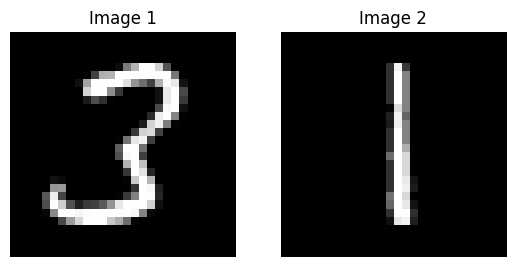

In [54]:
# Helper function to denormalize and plot images
def denormalize(img):
    img = img * 0.5 + 0.5  # Denormalize
    return img

fig, axs = plt.subplots(1, 2)
axs[0].imshow(denormalize(image1).squeeze(), cmap='gray')
axs[0].set_title('Image 1')
axs[0].axis('off')

axs[1].imshow(denormalize(image2).squeeze(), cmap='gray')
axs[1].set_title('Image 2')
axs[1].axis('off')

plt.show()


In [55]:

in_channels = 1
time_embedding_dim = 256
timesteps = 1000
base_dim = 64
dim_mults = [2, 4]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MNISTDiffusion(
    28,
    in_channels,
    timesteps=timesteps,
    time_embedding_dim=time_embedding_dim,
    base_dim=base_dim,
    dim_mults=dim_mults,
)
ckpt = torch.load('src/best_model.pt', map_location=device)
model.load_state_dict(ckpt["model"])
model.to(device)
model.eval()

MNISTDiffusion(
  (model): Unet(
    (init_conv): ConvBnSiLu(
      (module): Sequential(
        (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
    )
    (time_embedding): Embedding(1000, 256)
    (encoder_blocks): ModuleList(
      (0): EncoderBlock(
        (conv0): Sequential(
          (0): ResidualBottleneck(
            (branch1): Sequential(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): ConvBnSiLu(
                (module): Sequential(
                  (0): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
                  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                  (2): SiLU(inplace=True)
          

100%|██████████| 200/200 [00:01<00:00, 110.13it/s]


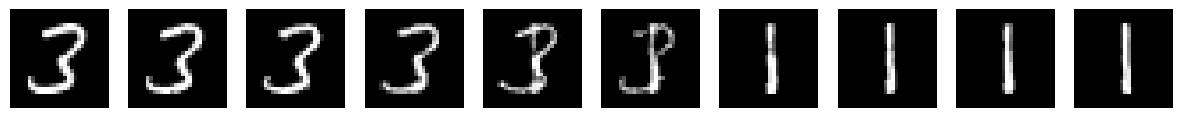

In [58]:

# Run the denoising process on the interpolated images
# this is a number out of 1000
num_denoising_steps = 200  # Define the number of denoising steps

denoised_images = [model.sample_from_t(num_denoising_steps, img.to(device)).cpu() for img in interpolated_images]

# Plot denoised images
fig, axs = plt.subplots(1, steps, figsize=(15, 2))
for i, img in enumerate(denoised_images):
    axs[i].imshow(denormalize(img).squeeze(), cmap='gray')
    axs[i].axis('off')

plt.show()

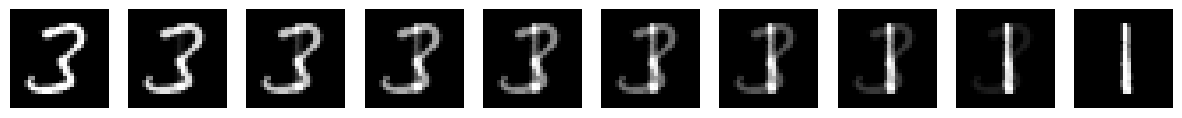

In [57]:
# Linear interpolation function
def linear_interpolate(img1, img2, steps):
    return [(1 - alpha) * img1 + alpha * img2 for alpha in torch.linspace(0, 1, steps)]

steps = 10  # Number of interpolation steps
interpolated_images = linear_interpolate(image1, image2, steps)

# Plot interpolated images
fig, axs = plt.subplots(1, steps, figsize=(15, 2))
for i, img in enumerate(interpolated_images):
    axs[i].imshow(denormalize(img).squeeze(), cmap='gray')
    axs[i].axis('off')

plt.show()

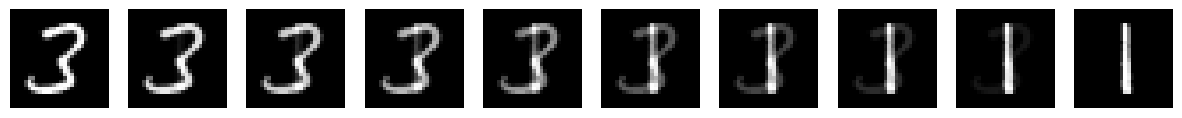

In [66]:
# Run the denoising process on the interpolated images
# this is a number out of 1000
denoising_time = 500  # Define the number of denoising steps
step_distance = 0.2 # Distance along grad we move

def denoise_image_single(image, denoising_time, step_dist=1):
    denoising_time = torch.tensor(denoising_time).to(device)
    return image - step_dist*model.model(image, denoising_time)

denoised_images = [denoise_image_single(img.to(device), denoising_time, step_distance).detach().cpu() for img in interpolated_images]

# Plot denoised images
fig, axs = plt.subplots(1, steps, figsize=(15, 2))
for i, img in enumerate(denoised_images):
    axs[i].imshow(denormalize(img).squeeze(), cmap='gray')
    axs[i].axis('off')

plt.show()

In [ ]:
# Define transformations and load dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

mnist = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
data_loader = torch.utils.data.DataLoader(mnist, batch_size=2, shuffle=True)

# Get two random images
data_iter = iter(data_loader)
images, _ = next(data_iter)

image1 = images[0].unsqueeze(0)  # Add batch dimension
image2 = images[1].unsqueeze(0)
